In [2]:
import numpy as np
import pickle 
import matplotlib
import seaborn as sns   
import cmasher as cmr
from figure import * 

Fig 2a

In [3]:
#### bootstrapping the 1-p factor #### 
n, time_steps = 40, 16
Even_depo = np.zeros(shape=(22, time_steps))
for i in range(100):
    with open('bootstrapped_even_depo/bootstrapped_even_depo_'+str(i), 'rb') as f: 
        even_depo = pickle.load(f)
    Even_depo += even_depo
Even_depo = Even_depo/100

Odd_depo = np.zeros(shape=(20, time_steps))
for i in range(100):
    with open('bootstrapped_odd_depo/bootstrapped_odd_depo_'+str(i), 'rb') as f: 
        odd_depo = pickle.load(f)
    Odd_depo += odd_depo
Odd_depo = Odd_depo/100

In [4]:
# create the depo_matrix for each bootstrapped data
time_steps = 16
odr_local_imag = []

for index in range(100):    
    with open('bootstrapped_even_mxy/bootstrapped_even_'+str(index), 'rb') as f: 
        even_mxy = pickle.load(f)
    with open('bootstrapped_even_pxy/bootstrapped_even_'+str(index), 'rb') as f: 
        even_pxy = pickle.load(f)
    with open('bootstrapped_odd_mxy/bootstrapped_odd_'+str(index), 'rb') as f: 
        odd_mxy = pickle.load(f)
    with open('bootstrapped_odd_pxy/bootstrapped_odd_'+str(index), 'rb') as f: 
        odd_pxy = pickle.load(f)

    depo_jj_matrix  = np.zeros(shape=(n, 16)) 
    for i in range(time_steps):
        for pair in range(11):
            depo_iz = even_mxy[i][pair][0] / Even_depo[2*pair+1 ,i]
            depo_zi = even_mxy[i][pair][1] / Even_depo[2*pair ,i]
            term_1 = depo_iz - depo_zi
            depo_iz_2 = even_pxy[i][pair][0] / Even_depo[2*pair+1 ,i]
            depo_zi_2 = even_pxy[i][pair][1] / Even_depo[2*pair ,i]
            term_2 = depo_iz_2 - depo_zi_2
            depo_jj_matrix[pair*2][i] = term_1-term_2

    start =  1 
    for i in range(time_steps):
        for pair in range(10): 
            depo_iz = odd_mxy[i][pair][0] / Odd_depo[2*pair+1 ,i]
            depo_zi = odd_mxy[i][pair][1] / Odd_depo[2*pair ,i]
            term_1 = depo_iz - depo_zi
            depo_iz_2 = odd_pxy[i][pair][0] / Odd_depo[2*pair+1 ,i]
            depo_zi_2 = odd_pxy[i][pair][1] / Odd_depo[2*pair ,i]
            term_2 = depo_iz_2 - depo_zi_2
            depo_jj_matrix[start+pair*2][i] = term_1-term_2

    odr_local_imag.append(depo_jj_matrix*-1/(16))

In [5]:
with open('bootstrapped_even_mxy/bootstrapped_even_'+str(index), 'rb') as f: 
    even_mxy = pickle.load(f)
with open('bootstrapped_even_pxy/bootstrapped_even_'+str(index), 'rb') as f: 
    even_pxy = pickle.load(f)

def get_total_mean_lc(lc_data, index):
    n = 40 
    Total = np.zeros(shape=(100 , 16))
    for i in range(100): 
        Total[i, :] = lc_data[i][index,:]
    return Total 

with open('../mps_40_results','rb') as f:
    mps_result = pickle.load(f)


['#162B44', '#255961', '#677C6C', '#B19E6C', '#F1CB57']


/var/folders/jt/xv4mn94150s9b4bx13g2y61w0000gp/T/ipykernel_59614/128851154.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('cividis')
/var/folders/jt/xv4mn94150s9b4bx13g2y61w0000gp/T/ipykernel_59614/128851154.py:13: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(times, np.mean(lc, axis=0), yerr=2*np.std(lc, axis=0),


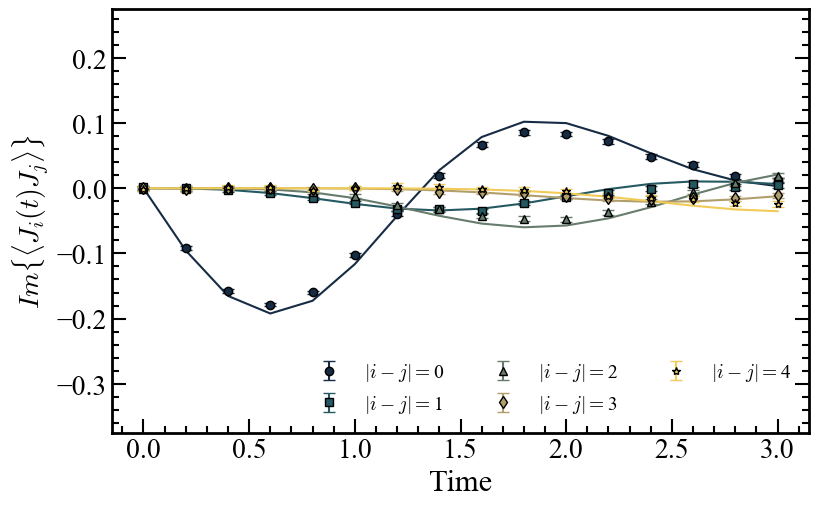

In [6]:
fig, ax = plt.subplots(figsize=(9,5.5))
plt.rcParams['mathtext.fontset'] ='cm' 
times = np.arange(0,0.80,0.05)*4
cmap = matplotlib.cm.get_cmap('cividis') 
color = 'cmr.eclipse'
cmap = cmr.take_cmap_colors(color, 5, cmap_range=(0.2, 0.9), return_fmt='hex')
print(cmap)
lines = 5
marker = ['o','s', '^', 'd',"*"]
for i in range(lines):
    num_mps = [np.imag(mps_result[j][i]/(16)) for j in range(16)]
    lc = get_total_mean_lc(odr_local_imag ,i)
    ax.errorbar(times, np.mean(lc, axis=0), yerr=2*np.std(lc, axis=0), 
                color=cmap[i],capsize=4, capthick= 1, fmt='o',label = '$|i-j |= $'+str(i),
                markeredgecolor='black', zorder=5, marker =marker[i])
    ax.plot(times, num_mps, color=cmap[i])
ax.set_ylabel('$ \Re \langle J_0(t)J_0 \\rangle  $', font='Times new roman', fontsize=22)
adjust_ax(ax)
ax.set_ylim(-0.9/(4), 0.6/(4))
ax.set_ylim(-1.5/(4), 1.1/(4))
ax.set_xlabel('Time', font='Times new roman', fontsize=22)
ax.set_ylabel('$ Im \{ \langle J_i(t)J_j  \\rangle \}$', font='Times new roman', fontsize=20)
adjust_ax(ax)
ax.legend(prop=font4, ncol=3, frameon=False,loc = 4)

(1-p)factor

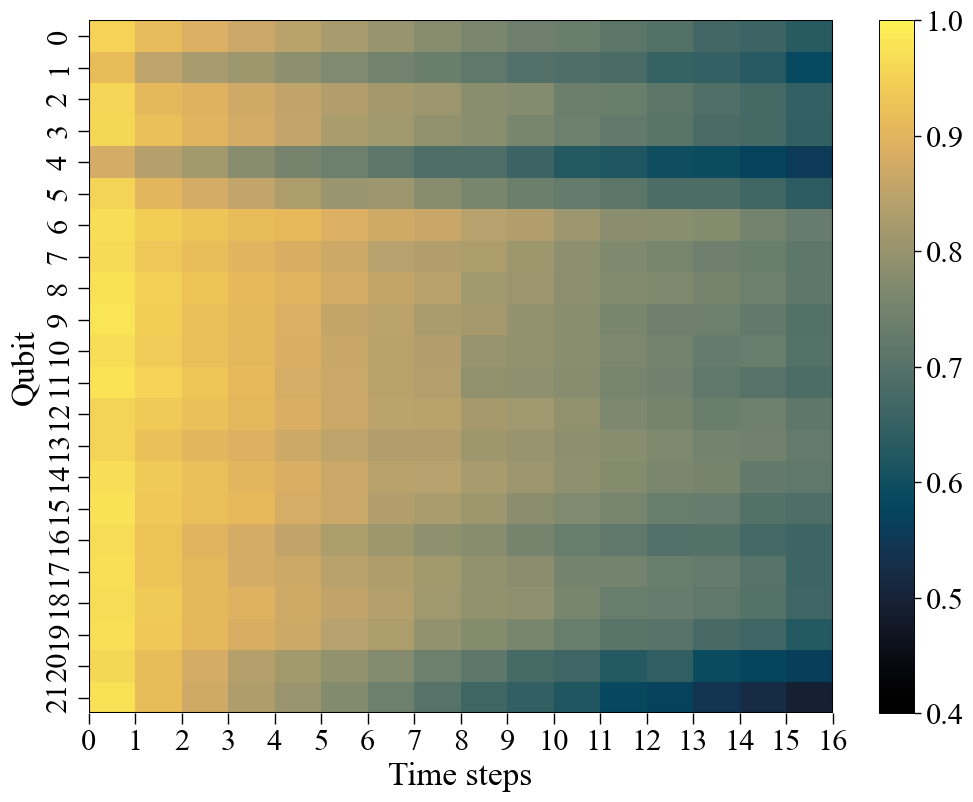

In [31]:
import seaborn as sns

from figure import * ### Green's function 
fig, ax = plt.subplots(figsize=(12,9))
x, y = np.meshgrid(np.arange(Even_depo.shape[1]), np.arange(Even_depo.shape[0]))
cmap = 'cmr.eclipse'
heatmap = sns.heatmap(np.real(Even_depo), cbar=True, cmap=cmap, annot=False, vmin=0.4, vmax=1, rasterized=True,)

ax.set_xticks(np.arange(0,time_steps+1,1),np.arange(0,time_steps+1,1))

labels = ax.get_yticklabels() + ax.get_xticklabels()
[label.set_fontname('Times new roman') for label in labels]
[label.set_weight('normal') for label in labels]
ax.tick_params(axis='y', labelsize =22, direction='out', length=8, width=1,  left=True)
ax.tick_params(axis='x', labelsize =22, direction='out', length=8, width=1,  bottom=True)
ax.set_xlabel('Time steps', font=font1)
ax.set_ylabel('Qubit', font=font1)

ax.hlines(0, 0,41, color='black'), ax.hlines(Even_depo.shape[0], 0,41, color='black')
ax.vlines(0, 0,41, color='black'), ax.vlines(Even_depo.shape[1], 0,41, color='black')

cbar = heatmap.collections[0].colorbar  # Access the colorbar
cbar.outline.set_edgecolor('black')  # Set border color
cbar.outline.set_linewidth(0.7)   
labels = cbar.ax.get_yticklabels() 
[label.set_fontname('Times new roman') for label in labels]
[label.set_weight('normal') for label in labels]
cbar.ax.tick_params(length=5, width=1, color='black',labelsize =22) 

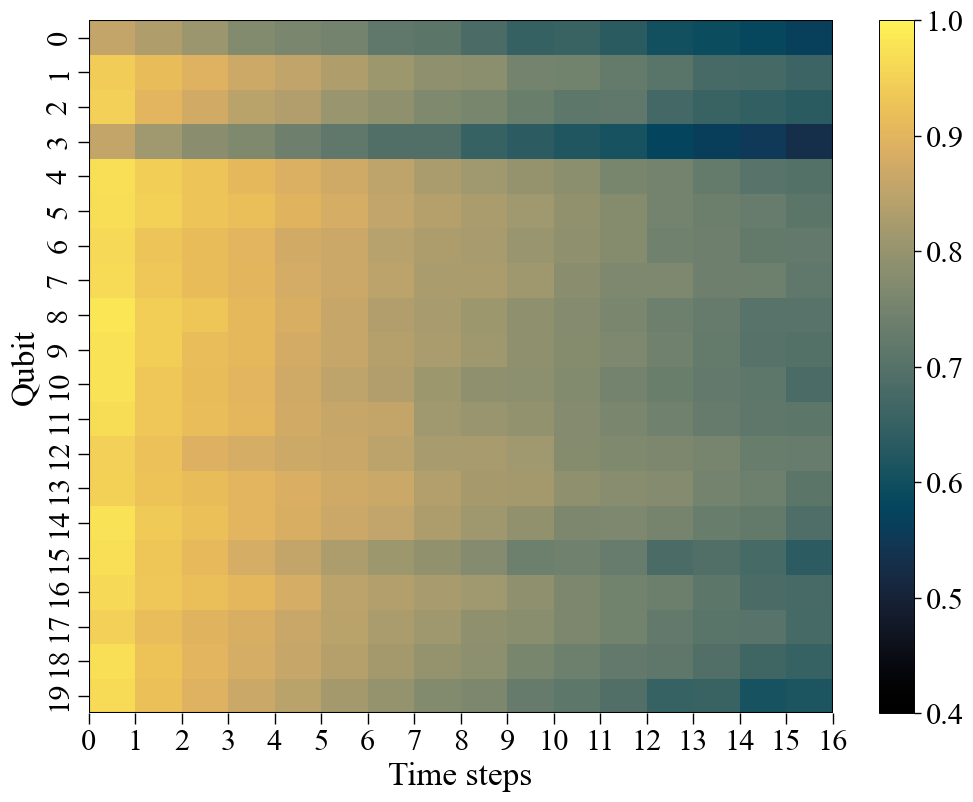

In [32]:
import seaborn as sns

from figure import * ### Green's function 
fig, ax = plt.subplots(figsize=(12,9))
x, y = np.meshgrid(np.arange(Odd_depo.shape[1]), np.arange(Odd_depo.shape[0]))
cmap = 'cmr.eclipse'
heatmap = sns.heatmap(np.real(Odd_depo), cbar=True, cmap=cmap, annot=False, vmin=0.4, vmax=1, rasterized=True,)

ax.set_xticks(np.arange(0,time_steps+1,1),np.arange(0,time_steps+1,1))

labels = ax.get_yticklabels() + ax.get_xticklabels()
[label.set_fontname('Times new roman') for label in labels]
[label.set_weight('normal') for label in labels]
ax.tick_params(axis='y', labelsize =22, direction='out', length=8, width=1,  left=True)
ax.tick_params(axis='x', labelsize =22, direction='out', length=8, width=1,  bottom=True)
ax.set_xlabel('Time steps', font=font1)
ax.set_ylabel('Qubit', font=font1)

ax.hlines(0, 0,41, color='black'), ax.hlines(Odd_depo.shape[0], 0,41, color='black')
ax.vlines(0, 0,41, color='black'), ax.vlines(Odd_depo.shape[1], 0,41, color='black')

cbar = heatmap.collections[0].colorbar  # Access the colorbar
cbar.outline.set_edgecolor('black')  # Set border color
cbar.outline.set_linewidth(0.7)   
labels = cbar.ax.get_yticklabels() 
[label.set_fontname('Times new roman') for label in labels]
[label.set_weight('normal') for label in labels]
cbar.ax.tick_params(length=5, width=1, color='black',labelsize =22) 